<a href="https://colab.research.google.com/github/debashreebanerjee/Seq-rHpy-calculation/blob/main/esm_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESM-2 Protein Contact Prediction

This notebook implements the following changes to the original pipeline:

1. **Decoder/models:** Decision Tree, Random Forest, XGBoost, LightGBM, AdaBoost, and MLP.
2. **Residue pairs:** remove **only the diagonal** (`i == j`). Adjacent pairs and all other residue pairs are retained.
3. **Chains:** process **every PDB-chain entry in the converted metadata CSV**. Each chain is treated independently; full pairwise feature files are not cached.
4. **Structure/contact definition:** a residue pair is a contact when **any non-hydrogen (heavy) atom** from residue i is within the contact threshold of any heavy atom from residue j.
5. **Train/validation split:** group by **PDB ID**, so all chains from the same PDB stay in the same split and cannot leak across train/validation.
6. **Plots:** process/evaluate all available chains, but create contact-map plots for only **six selected held-out chains**.

### Contact threshold
 **4.25 Å** threshold.


In [ ]:
# Installing dependencies
!pip install -q fair-esm biopython xgboost lightgbm

In [ ]:
import os,gc,time,random,warnings
from pathlib import Path
import numpy as np,pandas as pd,torch,esm,joblib
from Bio.PDB import PDBParser
from scipy.spatial import cKDTree
from esm.modules import symmetrize,apc
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score,roc_auc_score,precision_score,recall_score,f1_score,precision_recall_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
SEED=42; np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

CSV_PATH=Path('/kaggle/input/allproteins/allproteins.csv')
BASE_DIR=Path('/kaggle/working/esm_contact_v3');
FEATURE_DIR=BASE_DIR/'features';
MODEL_DIR=BASE_DIR/'models';
RESULT_DIR=BASE_DIR/'results';
PDB_DIR=BASE_DIR/'pdb_files'

for p in [FEATURE_DIR,MODEL_DIR,RESULT_DIR,PDB_DIR]: p.mkdir(parents=True,exist_ok=True)
CONTACT_THRESHOLD=4.25
TEST_FRACTION=0.15
VALIDATION_FRACTION_OF_REMAINING=0.15/0.85
MAX_TRAIN_SAMPLES=150000; NEGATIVE_TO_POSITIVE=5
MLP_EPOCHS=200
MODEL_SELECTION_METRIC='overall_average_precision'
N_FEATURES=33*20; N_PLOT_CHAINS=6
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',DEVICE); print('CSV:',CSV_PATH); print('Contact:',CONTACT_THRESHOLD,'A minimum heavy-atom distance'); print('MLP max epochs:',MLP_EPOCHS)

Device: cuda
CSV: /kaggle/input/allproteins/allproteins.csv
Contact: 4.25 A minimum heavy-atom distance
MLP max epochs: 200


In [ ]:
import os
from pathlib import Path

CLEAN_OLD_ARTIFACTS = True

if CLEAN_OLD_ARTIFACTS:
    # Old full-feature cache: potentially many GB.
    if FEATURE_DIR.exists():
        removed = 0
        for f in FEATURE_DIR.glob("*.npz"):
            try:
                f.unlink()
                removed += 1
            except OSError:
                pass
        print(f"Removed {removed} old cached feature files.")

    # Large temporary/model-input files that can be regenerated.
    removable = [
        RESULT_DIR / "train_X.dat",
        RESULT_DIR / "train_y.dat",
        RESULT_DIR / "test_y.dat",
        RESULT_DIR / "test_score.dat",
        RESULT_DIR / "train_validation_test_split.csv",
        RESULT_DIR / "test_protein_contact_predictions.csv",
        RESULT_DIR / "test_protein_contact_summary.csv",
    ]
    removable += list(RESULT_DIR.glob("tmp_val_*.dat"))

    removed_bytes = 0
    for f in removable:
        if f.exists():
            try:
                removed_bytes += f.stat().st_size
                f.unlink()
            except OSError:
                pass

    print(f"Removed regenerable temporary/output files: {removed_bytes/1024**3:.2f} GB")

print("Disk-safe mode ready.")


Removed 478 old cached feature files.
Removed regenerable temporary/output files: 0.00 GB
Disk-safe mode ready.


In [ ]:
# Kaggle: no manual upload is needed. Input files are mounted under /kaggle/input.
print('Kaggle input ready.')

Kaggle input ready.


In [ ]:
# CELL: Convert PDB-code-only CSV → Full Protein Metadata CSV


import os
import re
import requests
import pandas as pd
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa, protein_letters_3to1

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
INPUT_CSV = "/kaggle/input/datasets/raghavg02/pdb-codes/pdb_codes.csv"
OUTPUT_CSV = "/kaggle/working/proteins_metadata.csv"

# Use the same Path object defined in Cell 3
PDB_DIR = BASE_DIR / "pdb_files"
PDB_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Read PDB-code-only CSV
# ------------------------------------------------------------
codes_df = pd.read_csv(INPUT_CSV)

print("Input columns:", codes_df.columns.tolist())
print("Number of rows:", len(codes_df))

# Automatically find the PDB-code column
possible_code_cols = [
    "pdb_id",
    "pdb_code",
    "code",
    "pdb",
    "PDB",
    "PDB_ID"
]

code_col = None

for col in possible_code_cols:
    if col in codes_df.columns:
        code_col = col
        break

# If there is only one column, use it automatically
if code_col is None and len(codes_df.columns) == 1:
    code_col = codes_df.columns[0]

if code_col is None:
    raise ValueError(
        f"Could not identify PDB-code column. "
        f"Available columns: {codes_df.columns.tolist()}"
    )

PDB_CODES = (
    codes_df[code_col]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .tolist()
)

print(f"Using column: {code_col}")
print(f"Unique PDB codes: {len(set(PDB_CODES))}")


# ------------------------------------------------------------
# Extract chains + sequences
# ------------------------------------------------------------
parser = PDBParser(QUIET=True)


def extract_protein_chains(pdb_id, pdb_path):

    structure = parser.get_structure(
        pdb_id,
        pdb_path
    )

    results = []

    # Use first model
    model = next(structure.get_models())

    for chain in model:

        chain_id = chain.id

        sequence = []
        residues = []

        for residue in chain:

            # Ignore waters / ligands / non-amino-acid residues
            if not is_aa(residue, standard=True):
                continue

            resname = residue.get_resname().strip().upper()

            try:
                aa = protein_letters_3to1[resname]
            except KeyError:
                continue

            sequence.append(aa)
            residues.append(residue)

        if len(sequence) == 0:
            continue

        sequence = "".join(sequence)

        protein_chain_id = f"{pdb_id.upper()}_{chain_id}"

        results.append({
            "protein_chain_id": protein_chain_id,
            "pdb_id": pdb_id.upper(),
            "chain": chain_id,
            "sequence": sequence,
            "length": len(sequence)
        })

    return results


# ------------------------------------------------------------
# Process all PDB codes
# ------------------------------------------------------------
all_proteins = []
failed_downloads = []
failed_parsing = []

for idx, pdb_id in enumerate(PDB_CODES, start=1):

    print(
        f"[{idx}/{len(PDB_CODES)}] "
        f"Processing {pdb_id}"
    )

    pdb_path = download_pdb(pdb_id)

    if pdb_path is None:
        failed_downloads.append(pdb_id)
        continue

    try:

        chains = extract_protein_chains(
            pdb_id,
            pdb_path
        )

        if len(chains) == 0:
            failed_parsing.append(pdb_id)
            continue

        all_proteins.extend(chains)

        print(
            f"    Found {len(chains)} protein chain(s)"
        )

    except Exception as e:

        print(
            f"    Parsing failed: {e}"
        )

        failed_parsing.append(pdb_id)


# ------------------------------------------------------------
# Create the dataframe expected by downstream cells
# ------------------------------------------------------------
proteins_df = pd.DataFrame(all_proteins)

if len(proteins_df) == 0:
    raise RuntimeError(
        "No protein chains were successfully extracted."
    )

# Remove duplicate PDB-chain entries
proteins_df = (
    proteins_df
    .drop_duplicates(subset=["protein_chain_id"])
    .reset_index(drop=True)
)

# Save
proteins_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("CONVERSION COMPLETE")
print("=" * 60)

print(f"Input PDB codes       : {len(PDB_CODES)}")
print(f"Unique PDB codes      : {len(set(PDB_CODES))}")
print(f"Protein chains found  : {len(proteins_df)}")
print(f"Failed downloads      : {len(failed_downloads)}")
print(f"Failed parsing        : {len(failed_parsing)}")
print(f"Output CSV            : {OUTPUT_CSV}")

print("\nColumns:")
print(proteins_df.columns.tolist())

print("\nFirst 5 rows:")
display(proteins_df.head())

Input columns: ['pdb_id']
Number of rows: 732
Using column: pdb_id
Unique PDB codes: 732
[1/732] Processing 1HTR
    Found 2 protein chain(s)
[2/732] Processing 1H9H
    Found 2 protein chain(s)
[3/732] Processing 1GU2
    Found 2 protein chain(s)
[4/732] Processing 1G3P
    Found 1 protein chain(s)
[5/732] Processing 1FVK
    Found 2 protein chain(s)
[6/732] Processing 1EDM
    Found 2 protein chain(s)
[7/732] Processing 1EAJ
    Found 2 protein chain(s)
[8/732] Processing 1DZK
    Found 2 protein chain(s)
[9/732] Processing 1DOK
    Found 2 protein chain(s)
[10/732] Processing 1B3A
    Found 2 protein chain(s)
[11/732] Processing 1AGQ
    Found 4 protein chain(s)
[12/732] Processing 1VHU
    Found 1 protein chain(s)
[13/732] Processing 1UWC
    Found 2 protein chain(s)
[14/732] Processing 1UT1
    Found 6 protein chain(s)
[15/732] Processing 1ST9
    Found 2 protein chain(s)
[16/732] Processing 1SMO
    Found 2 protein chain(s)
[17/732] Processing 1RGX
    Found 3 protein chain(s)
[1

,protein_chain_id,pdb_id,chain,sequence,length
0,1HTR_P,1HTR,P,AVVKVPLKKFKSIRETMKEKGLLGEFLRTHKYDPAWKYRFGDL,43
1,1HTR_B,1HTR,B,SVTYEPMAYMDAAYFGEISIGTPPQNFLVLFDTGSSNLWVPSVYCQ...,329
2,1H9H_E,1H9H,E,IVGGYTSAANSIPYQVSLNSGSHFSGGSLINSQWVVSAAHSYKSRI...,223
3,1H9H_I,1H9H,I,GCPRILIRCKQDSDSLAGCVCGPNGFSGSP,30
4,1GU2_A,1GU2,A,DVTNAEKLVYKYTNIAHSANPMYEAPSITDGKIFFNRKFKTPSGKE...,124


In [ ]:
# ============================================================
# CELL: Load Converted Protein Metadata
# ============================================================

import pandas as pd

METADATA_CSV = "/kaggle/working/proteins_metadata.csv"

proteins_df = pd.read_csv(METADATA_CSV)

required_cols = {
    "protein_chain_id",
    "pdb_id",
    "chain",
    "sequence",
    "length"
}

missing = required_cols - set(proteins_df.columns)

if missing:
    raise ValueError(
        f"Missing CSV columns: {sorted(missing)}"
    )

proteins_df = proteins_df[
    [
        "protein_chain_id",
        "pdb_id",
        "chain",
        "sequence",
        "length"
    ]
].copy()

print(f"Loaded {len(proteins_df)} protein chains")
display(proteins_df.head())

Loaded 1333 protein chains


,protein_chain_id,pdb_id,chain,sequence,length
0,1HTR_P,1HTR,P,AVVKVPLKKFKSIRETMKEKGLLGEFLRTHKYDPAWKYRFGDL,43
1,1HTR_B,1HTR,B,SVTYEPMAYMDAAYFGEISIGTPPQNFLVLFDTGSSNLWVPSVYCQ...,329
2,1H9H_E,1H9H,E,IVGGYTSAANSIPYQVSLNSGSHFSGGSLINSQWVVSAAHSYKSRI...,223
3,1H9H_I,1H9H,I,GCPRILIRCKQDSDSLAGCVCGPNGFSGSP,30
4,1GU2_A,1GU2,A,DVTNAEKLVYKYTNIAHSANPMYEAPSITDGKIFFNRKFKTPSGKE...,124


In [ ]:

# ============================================================
# AMINO-ACID DEFINITIONS + PDB HELPERS
# ============================================================

STANDARD_AA = {
    "ALA", "ARG", "ASN", "ASP", "CYS",
    "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO",
    "SER", "THR", "TRP", "TYR", "VAL"
}

AA3_TO_AA1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V"
}

parser = PDBParser(QUIET=True)

def download_pdb(pdb_id: str, out_dir: Path = Path("pdb_files")) -> Path:
    """Download one PDB file if it is not already present."""
    out_dir.mkdir(exist_ok=True)
    pdb_path = out_dir / f"{pdb_id}.pdb"
    if pdb_path.exists() and pdb_path.stat().st_size > 0:
        return pdb_path

    import requests
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    pdb_path.write_bytes(response.content)
    return pdb_path


def is_hydrogen(atom) -> bool:
    """Return True for H/D atoms, using element when available and atom name as fallback."""
    element = str(getattr(atom, "element", "") or "").strip().upper()
    name = atom.get_name().strip().upper()
    if element in {"H", "D"}:
        return True
    # PDB hydrogen atom names generally begin with H or a digit followed by H.
    if name.startswith("H"):
        return True
    if len(name) >= 2 and name[0].isdigit() and name[1] == "H":
        return True
    return False


def extract_chain_heavy_atoms(chain):
    """
    Extract one sequence position per standard amino-acid residue.
    For each residue, store all non-hydrogen atom coordinates.
    """
    sequence = []
    residue_numbers = []
    residue_atom_coords = []

    for residue in chain:
        resname = residue.get_resname().strip().upper()
        if resname not in STANDARD_AA:
            continue

        atoms = []
        for atom in residue.get_atoms():
            if is_hydrogen(atom):
                continue
            atoms.append(atom.coord)

        # Keep the residue only if at least one heavy atom is resolved.
        if len(atoms) == 0:
            continue

        sequence.append(AA3_TO_AA1[resname])
        residue_numbers.append(residue.id[1])
        residue_atom_coords.append(np.asarray(atoms, dtype=np.float32))

    return "".join(sequence), residue_numbers, residue_atom_coords


def make_heavy_atom_contact_map(residue_atom_coords, threshold=CONTACT_THRESHOLD):
    """
    Residue i and residue j are contacts if ANY heavy-atom pair is closer
    than the threshold. Only off-diagonal residue contacts are retained.
    """
    L = len(residue_atom_coords)
    contacts = np.zeros((L, L), dtype=np.int8)

    if L == 0:
        return contacts

    all_coords = np.concatenate(residue_atom_coords, axis=0)
    residue_index = np.concatenate([
        np.full(len(coords), i, dtype=np.int32)
        for i, coords in enumerate(residue_atom_coords)
    ])

    tree = cKDTree(all_coords)
    atom_pairs = tree.query_pairs(r=threshold, output_type="ndarray")

    if atom_pairs.size:
        ri = residue_index[atom_pairs[:, 0]]
        rj = residue_index[atom_pairs[:, 1]]
        keep = ri != rj
        ri = ri[keep]
        rj = rj[keep]
        contacts[ri, rj] = 1
        contacts[rj, ri] = 1

    # Explicitly remove residue self-contacts.
    np.fill_diagonal(contacts, 0)
    return contacts

print("PDB/heavy-atom helper functions ready.")


PDB/heavy-atom helper functions ready.


In [ ]:

# ============================================================
# LOAD ESM-2 650M
# ============================================================

print("===== LOADING ESM-2 =====")
esm_model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
esm_model.eval()
esm_model = esm_model.to(DEVICE)

batch_converter = alphabet.get_batch_converter()

print("ESM-2 loaded successfully.")
print("33 layers × 20 heads = 660 attention features per residue pair.")


===== LOADING ESM-2 =====
ESM-2 loaded successfully.
33 layers × 20 heads = 660 attention features per residue pair.


In [ ]:
# STRUCTURE / CONTACT SCAN

def compute_chain_features(protein_chain_id, pdb_id, chain_id):
    """
    Generate one chain's ESM pair features and true labels on demand.

    Returns:
        X          : [L(L-1)/2, 660] float32
        y          : [L(L-1)/2] int8
        pair_i/j   : unique i<j residue indices
        sequence   : PDB-derived sequence
        residue_numbers : PDB residue numbers
    """
    pdb_file = download_pdb(str(pdb_id), PDB_DIR)
    structure = parser.get_structure(str(pdb_id), str(pdb_file))
    pdb_model = structure[0]

    if str(chain_id) not in pdb_model:
        raise ValueError(f"Chain {chain_id} not found in PDB {pdb_id}")

    chain = pdb_model[str(chain_id)]
    sequence, residue_numbers, residue_atom_coords = extract_chain_heavy_atoms(chain)
    L = len(sequence)

    if L < 2:
        raise ValueError(f"Too short ({L})")

    contacts = make_heavy_atom_contact_map(
        residue_atom_coords,
        threshold=CONTACT_THRESHOLD
    )

    _, _, tokens = batch_converter([(str(protein_chain_id), sequence)])
    tokens = tokens.to(DEVICE)

    with torch.no_grad():
        results = esm_model(
            tokens,
            need_head_weights=True,
            return_contacts=False
        )

    attention = results["attentions"][0][..., 1:-1, 1:-1]
    pair_i, pair_j = np.triu_indices(L, k=1)
    pair_i_t = torch.as_tensor(pair_i, device=DEVICE, dtype=torch.long)
    pair_j_t = torch.as_tensor(pair_j, device=DEVICE, dtype=torch.long)

    n_pairs = len(pair_i)
    X = np.empty(
        (n_pairs, N_FEATURES),
        dtype=np.float32
    )

    feature_idx = 0
    for layer in range(attention.shape[0]):
        for head in range(attention.shape[1]):
            A = apc(symmetrize(attention[layer, head]))
            X[:, feature_idx] = (
                A[pair_i_t, pair_j_t]
                .detach()
                .float()
                .cpu()
                .numpy()
            )
            feature_idx += 1
            del A

    y = contacts[pair_i, pair_j].astype(np.int8)

    del structure, pdb_model, chain, residue_atom_coords
    del contacts, results, attention, tokens, pair_i_t, pair_j_t

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        X,
        y,
        pair_i.astype(np.int32),
        pair_j.astype(np.int32),
        sequence,
        np.asarray(residue_numbers, dtype=np.int32)
    )


# Lightweight scan: no X matrix is written to disk.
all_records = []

for row in proteins_df.itertuples(index=False):
    pdb_id = str(row.pdb_id)
    chain_id = str(row.chain)
    protein_chain_id = str(row.protein_chain_id)

    print(f"\nScanning {protein_chain_id} ...")

    try:
        pdb_file = download_pdb(pdb_id, PDB_DIR)
        structure = parser.get_structure(pdb_id, str(pdb_file))
        pdb_model = structure[0]

        if chain_id not in pdb_model:
            print(f"  Chain {chain_id} not found. Skipping.")
            all_records.append({
                "protein_chain_id": protein_chain_id,
                "pdb_id": pdb_id,
                "chain": chain_id,
                "status": "chain_not_found"
            })
            continue

        chain = pdb_model[chain_id]
        sequence, residue_numbers, residue_atom_coords = extract_chain_heavy_atoms(chain)
        L = len(sequence)

        if L != int(row.length):
            print(
                f"  CSV length={int(row.length)}, "
                f"PDB-derived length={L}"
            )

        if L < 2:
            all_records.append({
                "protein_chain_id": protein_chain_id,
                "pdb_id": pdb_id,
                "chain": chain_id,
                "status": "too_short",
                "length": L
            })
            continue

        contacts = make_heavy_atom_contact_map(
            residue_atom_coords,
            threshold=CONTACT_THRESHOLD
        )

        pair_count = L * (L - 1) // 2
        positive_contacts = int(
            np.triu(contacts, k=1).sum()
        )

        all_records.append({
            "protein_chain_id": protein_chain_id,
            "pdb_id": pdb_id,
            "chain": chain_id,
            "status": "ready",
            "length": L,
            "pairs": pair_count,
            "positive_contacts": positive_contacts
        })

        print(
            f"  Length: {L} | pairs: {pair_count} | "
            f"contacts: {positive_contacts}"
        )

    except Exception as e:
        print(f"  ERROR: {type(e).__name__}: {e}")
        all_records.append({
            "protein_chain_id": protein_chain_id,
            "pdb_id": pdb_id,
            "chain": chain_id,
            "status": f"error: {type(e).__name__}",
            "error_message": str(e)
        })

    finally:
        for name in [
            "structure", "pdb_model", "chain", "contacts",
            "residue_atom_coords"
        ]:
            globals().pop(name, None)
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

status_df = pd.DataFrame(all_records)
status_df.to_csv(
    RESULT_DIR / "feature_extraction_status.csv",
    index=False
)

print("\n========================================")
print("STRUCTURE SCAN SUMMARY")
print("========================================")
print(status_df["status"].value_counts(dropna=False))
print("\nCSV entries:", len(proteins_df))
print("Cached feature matrices: 0")
print("PDB files on disk:", len(list(PDB_DIR.glob("*.pdb"))))



Scanning 1HTR_P ...
  Length: 43 | pairs: 903 | contacts: 121

Scanning 1HTR_B ...
  Length: 329 | pairs: 53956 | contacts: 1382

Scanning 1H9H_E ...
  Length: 223 | pairs: 24753 | contacts: 970

Scanning 1H9H_I ...
  Length: 30 | pairs: 435 | contacts: 99

Scanning 1GU2_A ...
  Length: 124 | pairs: 7626 | contacts: 523

Scanning 1GU2_B ...
  Length: 123 | pairs: 7503 | contacts: 527

Scanning 1G3P_A ...
  Length: 191 | pairs: 18145 | contacts: 797

Scanning 1FVK_A ...
  Length: 188 | pairs: 17578 | contacts: 835

Scanning 1FVK_B ...
  Length: 188 | pairs: 17578 | contacts: 836

Scanning 1EDM_B ...
  Length: 39 | pairs: 741 | contacts: 138

Scanning 1EDM_C ...
  Length: 39 | pairs: 741 | contacts: 142

Scanning 1EAJ_A ...
  Length: 124 | pairs: 7626 | contacts: 519

Scanning 1EAJ_B ...
  Length: 120 | pairs: 7140 | contacts: 499

Scanning 1DZK_A ...
  Length: 148 | pairs: 10878 | contacts: 611

Scanning 1DZK_B ...
  Length: 148 | pairs: 10878 | contacts: 619

Scanning 1DOK_A ...
  Len

In [ ]:
# ============================================================
# BUILD PDB-GROUPED TRAIN / VALIDATION / TEST SPLIT (~70/15/15)
# ============================================================

saved_ids = set(
    status_df.loc[
        status_df.status.eq("ready"),
        "protein_chain_id"
    ]
)

work_df = (
    proteins_df[
        proteins_df.protein_chain_id.isin(saved_ids)
    ]
    .copy()
    .reset_index(drop=True)
)

lookup = (
    status_df
    .drop_duplicates("protein_chain_id")
    .set_index("protein_chain_id")
)

work_df["pairs"] = (
    work_df.protein_chain_id
    .map(lookup.pairs)
    .fillna(0)
    .astype(int)
)

work_df["positive_contacts"] = (
    work_df.protein_chain_id
    .map(lookup.positive_contacts)
    .fillna(0)
    .astype(int)
)

g1 = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_FRACTION,
    random_state=SEED
)

trainval_idx, test_idx = next(
    g1.split(work_df, groups=work_df.pdb_id)
)

trainval = work_df.iloc[trainval_idx].copy()
test_chain_df = work_df.iloc[test_idx].copy()

g2 = GroupShuffleSplit(
    n_splits=1,
    test_size=VALIDATION_FRACTION_OF_REMAINING,
    random_state=SEED
)

tr_idx, va_idx = next(
    g2.split(trainval, groups=trainval.pdb_id)
)

train_chain_df = (
    trainval.iloc[tr_idx]
    .copy()
    .reset_index(drop=True)
)

val_chain_df = (
    trainval.iloc[va_idx]
    .copy()
    .reset_index(drop=True)
)

test_chain_df = (
    test_chain_df
    .reset_index(drop=True)
)

train_chain_df["split"] = "train"
val_chain_df["split"] = "validation"
test_chain_df["split"] = "test"

work_df = pd.concat(
    [train_chain_df, val_chain_df, test_chain_df],
    ignore_index=True
)

assert not set(train_chain_df.pdb_id) & set(val_chain_df.pdb_id)
assert not set(train_chain_df.pdb_id) & set(test_chain_df.pdb_id)
assert not set(val_chain_df.pdb_id) & set(test_chain_df.pdb_id)

# Keep only a tiny split summary rather than the full pair-level data.
pd.DataFrame([
    {
        "split": "train",
        "chains": len(train_chain_df),
        "pdbs": train_chain_df.pdb_id.nunique(),
        "pairs": int(train_chain_df.pairs.sum()),
        "positive_contacts": int(train_chain_df.positive_contacts.sum())
    },
    {
        "split": "validation",
        "chains": len(val_chain_df),
        "pdbs": val_chain_df.pdb_id.nunique(),
        "pairs": int(val_chain_df.pairs.sum()),
        "positive_contacts": int(val_chain_df.positive_contacts.sum())
    },
    {
        "split": "test",
        "chains": len(test_chain_df),
        "pdbs": test_chain_df.pdb_id.nunique(),
        "pairs": int(test_chain_df.pairs.sum()),
        "positive_contacts": int(test_chain_df.positive_contacts.sum())
    }
]).to_csv(
    RESULT_DIR / "split_summary.csv",
    index=False
)

for n, d in [
    ("TRAIN", train_chain_df),
    ("VALIDATION", val_chain_df),
    ("TEST", test_chain_df)
]:
    print(
        f"{n}: {len(d)} chains | "
        f"{d.pdb_id.nunique()} PDBs | "
        f"{int(d.pairs.sum())} pairs | "
        f"{int(d.positive_contacts.sum())} contacts"
    )

print("PDB leakage check: PASSED")


TRAIN: 926 chains | 512 PDBs | 18138125 pairs | 660354 contacts
VALIDATION: 220 chains | 110 PDBs | 3983291 pairs | 156337 contacts
TEST: 187 chains | 110 PDBs | 3608263 pairs | 136783 contacts
PDB leakage check: PASSED


In [ ]:
n_train_chains = len(train_chain_df)

if n_train_chains == 0:
    raise RuntimeError("No training chains available.")

per_chain_quota = max(
    1,
    MAX_TRAIN_SAMPLES // n_train_chains
)

print("Training chains:", n_train_chains)
print("Per-chain quota:", per_chain_quota)
print("Maximum training rows:", MAX_TRAIN_SAMPLES)

train_X_path = RESULT_DIR / "train_X.dat"
train_y_path = RESULT_DIR / "train_y.dat"

# Remove stale files before recreating them.
for p in [train_X_path, train_y_path]:
    if p.exists():
        p.unlink()

train_X_mm = np.memmap(
    train_X_path,
    dtype=np.float32,
    mode="w+",
    shape=(MAX_TRAIN_SAMPLES, N_FEATURES)
)

train_y_mm = np.memmap(
    train_y_path,
    dtype=np.int8,
    mode="w+",
    shape=(MAX_TRAIN_SAMPLES,)
)

rng = np.random.default_rng(SEED)
train_cursor = 0
chains_used = 0

for n, row in enumerate(
    train_chain_df.itertuples(index=False),
    1
):
    try:
        (
            X,
            y,
            pair_i,
            pair_j,
            sequence,
            residue_numbers
        ) = compute_chain_features(
            row.protein_chain_id,
            row.pdb_id,
            row.chain
        )

        if len(y) == 0:
            continue

        quota = min(
            per_chain_quota,
            len(y),
            MAX_TRAIN_SAMPLES - train_cursor
        )

        pos = np.flatnonzero(y == 1)
        neg = np.flatnonzero(y == 0)

        pos_take = (
            min(
                len(pos),
                max(
                    1,
                    quota // (NEGATIVE_TO_POSITIVE + 1)
                )
            )
            if len(pos)
            else 0
        )

        neg_take = min(
            len(neg),
            quota - pos_take
        )

        if pos_take + neg_take < quota:
            pos_take += max(
                0,
                min(
                    len(pos) - pos_take,
                    quota - pos_take - neg_take
                )
            )

        pos_sel = (
            rng.choice(pos, size=pos_take, replace=False)
            if pos_take else np.array([], dtype=np.int64)
        )

        neg_sel = (
            rng.choice(neg, size=neg_take, replace=False)
            if neg_take else np.array([], dtype=np.int64)
        )

        selected = np.concatenate([pos_sel, neg_sel])
        rng.shuffle(selected)

        if len(selected):
            end = train_cursor + len(selected)
            train_X_mm[train_cursor:end] = X[selected]
            train_y_mm[train_cursor:end] = y[selected]
            train_cursor = end
            chains_used += 1

        del X, y, pair_i, pair_j
        del sequence, residue_numbers
        del pos, neg, pos_sel, neg_sel, selected
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if n % 25 == 0 or n == len(train_chain_df):
            print(
                f"Processed {n}/{len(train_chain_df)} chains; "
                f"training rows={train_cursor}"
            )

        if train_cursor >= MAX_TRAIN_SAMPLES:
            break

    except Exception as e:
        print(
            f"Training chain {row.protein_chain_id} failed: "
            f"{type(e).__name__}: {e}"
        )

train_X_mm.flush()
train_y_mm.flush()
del train_X_mm, train_y_mm
gc.collect()

if train_cursor == 0:
    raise RuntimeError("No training samples were created.")

TRAIN_SAMPLE_COUNT = int(train_cursor)

with open(
    RESULT_DIR / "train_sample_count.txt",
    "w"
) as f:
    f.write(str(TRAIN_SAMPLE_COUNT))

X_train = np.memmap(
    train_X_path,
    dtype=np.float32,
    mode="r",
    shape=(TRAIN_SAMPLE_COUNT, N_FEATURES)
)

y_train = np.memmap(
    train_y_path,
    dtype=np.int8,
    mode="r",
    shape=(TRAIN_SAMPLE_COUNT,)
)

print("\nTraining rows:", TRAIN_SAMPLE_COUNT)
print(
    "Chains contributing samples:",
    chains_used,
    "/",
    n_train_chains
)
print("Training positives:", int(np.sum(y_train)))
print("Training negatives:", int(np.sum(y_train == 0)))
print("Training prevalence:", float(np.mean(y_train)))


Training chains: 926
Per-chain quota: 161
Maximum training rows: 150000
Processed 25/926 chains; training rows=4025
Processed 50/926 chains; training rows=8050
Processed 75/926 chains; training rows=11799
Processed 100/926 chains; training rows=15673
Processed 125/926 chains; training rows=19698
Processed 150/926 chains; training rows=23723
Processed 175/926 chains; training rows=27748
Processed 200/926 chains; training rows=31773
Processed 225/926 chains; training rows=35798
Processed 250/926 chains; training rows=39823
Processed 275/926 chains; training rows=43848
Processed 300/926 chains; training rows=47873
Processed 325/926 chains; training rows=51773
Processed 350/926 chains; training rows=55647
Processed 375/926 chains; training rows=59672
Processed 400/926 chains; training rows=63697
Processed 425/926 chains; training rows=67722
Processed 450/926 chains; training rows=71622
Processed 475/926 chains; training rows=75647
Processed 500/926 chains; training rows=79514
Processed 525

In [ ]:
# ============================================================
# DEFINE FIVE DECODERS
# ============================================================
pos_count=int(np.sum(y_train==1)); neg_count=int(np.sum(y_train==0)); scale_pos_weight=neg_count/max(pos_count,1)
models={
'Decision Tree':DecisionTreeClassifier(max_depth=12,min_samples_leaf=5,class_weight='balanced',random_state=SEED),
'Random Forest':RandomForestClassifier(n_estimators=100,max_features='sqrt',min_samples_leaf=2,class_weight='balanced_subsample',n_jobs=-1,random_state=SEED),
'XGBoost':XGBClassifier(n_estimators=250,max_depth=6,learning_rate=.05,subsample=.8,colsample_bytree=.8,min_child_weight=2,objective='binary:logistic',eval_metric='logloss',tree_method='hist',scale_pos_weight=scale_pos_weight,n_jobs=-1,random_state=SEED),
'LightGBM':LGBMClassifier(n_estimators=250,num_leaves=31,learning_rate=.05,min_child_samples=20,subsample=.8,colsample_bytree=.8,scale_pos_weight=scale_pos_weight,verbosity=-1,n_jobs=-1,random_state=SEED),
'MLP':Pipeline([('scaler',StandardScaler()),('mlp',MLPClassifier(hidden_layer_sizes=(128,64),activation='relu',solver='adam',alpha=1e-4,batch_size=1024,learning_rate_init=1e-3,max_iter=MLP_EPOCHS,early_stopping=True,validation_fraction=.10,n_iter_no_change=10,random_state=SEED))])}
print('MLP max epochs:',MLP_EPOCHS); print(list(models))

MLP max epochs: 200
['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP']


In [ ]:
# ============================================================
# TRAIN ALL FIVE MODELS
# ============================================================
trained_models={}; training_summary=[]
for name,model in models.items():
    print('\nTRAINING:',name); start=time.time()
    X_train=np.memmap(RESULT_DIR/'train_X.dat',dtype=np.float32,mode='r',shape=(TRAIN_SAMPLE_COUNT,N_FEATURES))
    y_train=np.memmap(RESULT_DIR/'train_y.dat',dtype=np.int8,mode='r',shape=(TRAIN_SAMPLE_COUNT,))
    model.fit(X_train,y_train); elapsed=time.time()-start; trained_models[name]=model
    joblib.dump(model,MODEL_DIR/f'{name.lower().replace(" ","_")}.joblib')
    row={'model':name,'train_seconds':elapsed,'train_rows':TRAIN_SAMPLE_COUNT,'train_positive':int(y_train.sum()),'train_negative':int((y_train==0).sum())}
    if name=='MLP': row['mlp_epochs_completed']=getattr(model.named_steps['mlp'],'n_iter_',np.nan); print('MLP epochs completed:',row['mlp_epochs_completed'])
    training_summary.append(row); print(f'Time: {elapsed/60:.2f} min')
    del X_train,y_train; gc.collect()
pd.DataFrame(training_summary).to_csv(RESULT_DIR/'training_times.csv',index=False)


TRAINING: Decision Tree
Time: 4.03 min

TRAINING: Random Forest
Time: 6.32 min

TRAINING: XGBoost
Time: 1.45 min

TRAINING: LightGBM
Time: 0.88 min

TRAINING: MLP
MLP epochs completed: 16
Time: 0.28 min


# Training is complete in the previous cell. Training uses only the bounded disk-backed sample; no per-chain feature cache is needed.

In [ ]:
# ============================================================
# VALIDATION: OPTIMIZE THRESHOLD ON VALIDATION ONLY
# ============================================================


def predict_probability(model, X):
    return model.predict_proba(X)[:, 1]


def best_f1_threshold(y, s):
    p, r, t = precision_recall_curve(y, s)
    if len(t) == 0:
        return 0.5, 0.0
    f = (
        2 * p[:-1] * r[:-1]
        / np.maximum(p[:-1] + r[:-1], 1e-12)
    )
    k = int(np.nanargmax(f))
    return float(t[k]), float(f[k])


val_total_pairs = int(val_chain_df.pairs.sum())

if val_total_pairs <= 0:
    raise RuntimeError("Validation set contains no residue pairs.")

val_y_path = RESULT_DIR / "tmp_val_y.dat"

val_y_mm = np.memmap(
    val_y_path,
    dtype=np.int8,
    mode="w+",
    shape=(val_total_pairs,)
)

score_paths = {}
score_mmaps = {}

for name in trained_models:
    key = name.lower().replace(" ", "_")
    path = RESULT_DIR / f"tmp_val_score_{key}.dat"
    if path.exists():
        path.unlink()
    score_paths[name] = path
    score_mmaps[name] = np.memmap(
        path,
        dtype=np.float32,
        mode="w+",
        shape=(val_total_pairs,)
    )

validation_rows = []
cur = 0

for n, row in enumerate(
    val_chain_df.itertuples(index=False),
    1
):
    (
        X,
        y,
        pair_i,
        pair_j,
        sequence,
        residue_numbers
    ) = compute_chain_features(
        row.protein_chain_id,
        row.pdb_id,
        row.chain
    )

    a, b = cur, cur + len(y)
    val_y_mm[a:b] = y

    for name, model in trained_models.items():
        s = predict_probability(model, X)
        score_mmaps[name][a:b] = s

        validation_rows.append({
            "protein_chain_id": row.protein_chain_id,
            "pdb_id": row.pdb_id,
            "chain": row.chain,
            "model": name,
            "pairs": len(y),
            "positive_contacts": int(y.sum()),
            "average_precision": (
                average_precision_score(y, s)
                if y.sum() else np.nan
            ),
            "roc_auc": (
                roc_auc_score(y, s)
                if len(np.unique(y)) == 2
                else np.nan
            )
        })

    cur = b

    del X, y, pair_i, pair_j, sequence, residue_numbers
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        f"Validation {n}/{len(val_chain_df)}: "
        f"{row.protein_chain_id}"
    )

val_y_mm.flush()
for mm in score_mmaps.values():
    mm.flush()

validation_summary = []

for name in trained_models:
    y_val = np.memmap(
        val_y_path,
        dtype=np.int8,
        mode="r",
        shape=(val_total_pairs,)
    )

    s_val = np.memmap(
        score_paths[name],
        dtype=np.float32,
        mode="r",
        shape=(val_total_pairs,)
    )

    th, f1 = best_f1_threshold(
        y_val,
        s_val
    )

    pred = np.asarray(s_val) >= th

    rows = pd.DataFrame([
        r for r in validation_rows
        if r["model"] == name
    ])

    validation_summary.append({
        "model": name,
        "overall_average_precision":
            average_precision_score(y_val, s_val),
        "overall_roc_auc":
            roc_auc_score(y_val, s_val),
        "mean_chain_average_precision":
            rows.average_precision.mean(),
        "median_chain_average_precision":
            rows.average_precision.median(),
        "optimal_threshold": th,
        "validation_f1_at_optimal_threshold": f1,
        "validation_precision_at_optimal_threshold":
            precision_score(
                y_val, pred, zero_division=0
            ),
        "validation_recall_at_optimal_threshold":
            recall_score(
                y_val, pred, zero_division=0
            ),
        "validation_pairs": len(y_val),
        "validation_positive_contacts": int(y_val.sum())
    })

    print(
        name,
        "AP=",
        round(
            validation_summary[-1]["overall_average_precision"],
            5
        ),
        "optimal threshold=",
        th,
        "F1=",
        round(f1, 5)
    )

    del y_val, s_val, pred
    gc.collect()

validation_df = pd.DataFrame(validation_rows)

validation_summary_df = (
    pd.DataFrame(validation_summary)
    .sort_values(
        "overall_average_precision",
        ascending=False
    )
    .reset_index(drop=True)
)

validation_df.to_csv(
    RESULT_DIR / "per_chain_validation.csv",
    index=False
)

validation_summary_df.to_csv(
    RESULT_DIR / "validation_model_comparison.csv",
    index=False
)

print(validation_summary_df.to_string(index=False))

# Delete temporary validation arrays.
del val_y_mm
for mm in score_mmaps.values():
    del mm
gc.collect()

for p in [val_y_path, *score_paths.values()]:
    try:
        p.unlink()
    except FileNotFoundError:
        pass


Validation 1/220: 1FVK_A
Validation 2/220: 1FVK_B
Validation 3/220: 1R0R_E
Validation 4/220: 1R0R_I
Validation 5/220: 1LLF_A
Validation 6/220: 1LLF_B
Validation 7/220: 1KPT_A
Validation 8/220: 1KPT_B
Validation 9/220: 1K55_A
Validation 10/220: 1K55_B
Validation 11/220: 1K55_C
Validation 12/220: 1K55_D
Validation 13/220: 1DY5_A
Validation 14/220: 1DY5_B
Validation 15/220: 1ES9_A
Validation 16/220: 1EJG_A
Validation 17/220: 1EIZ_A
Validation 18/220: 1EF1_A
Validation 19/220: 1EF1_C
Validation 20/220: 1EF1_B
Validation 21/220: 1EF1_D
Validation 22/220: 1ECA_A
Validation 23/220: 1EAZ_A
Validation 24/220: 1DQI_A
Validation 25/220: 1DQI_B
Validation 26/220: 1DQI_C
Validation 27/220: 1DQI_D
Validation 28/220: 1DOS_A
Validation 29/220: 1DOS_B
Validation 30/220: 1DG6_A
Validation 31/220: 1D7P_M
Validation 32/220: 1CSE_E
Validation 33/220: 1CSE_I
Validation 34/220: 1C75_A
Validation 35/220: 1C5E_A
Validation 36/220: 1C5E_B
Validation 37/220: 1C5E_C
Validation 38/220: 1BQC_A
Validation 39/220: 1A

In [ ]:
# ============================================================
# SELECT FINAL MODEL + FREEZE VALIDATION THRESHOLD
# ============================================================
best_model_name=str(validation_summary_df.iloc[0]['model']); best_threshold=float(validation_summary_df.iloc[0]['optimal_threshold']); final_model=trained_models[best_model_name]
print('Selected model:',best_model_name); print('Validation AP:',validation_summary_df.iloc[0]['overall_average_precision']); print('Frozen F1-optimal threshold:',best_threshold); print('TEST WILL NOT BE USED FOR OPTIMIZATION.')

Selected model: LightGBM
Validation AP: 0.8440299095777453
Frozen F1-optimal threshold: 0.9153476357460022
TEST WILL NOT BE USED FOR OPTIMIZATION.


In [ ]:
# ============================================================
# FINAL TEST EVALUATION — UNTOUCHED TEST SET
# ============================================================

test_total_pairs = int(test_chain_df.pairs.sum())

if test_total_pairs <= 0:
    raise RuntimeError("Test set contains no residue pairs.")

test_y_path = RESULT_DIR / "test_y.dat"
test_score_path = RESULT_DIR / "test_score.dat"

for p in [test_y_path, test_score_path]:
    if p.exists():
        p.unlink()

test_y = np.memmap(
    test_y_path,
    dtype=np.int8,
    mode="w+",
    shape=(test_total_pairs,)
)

test_score = np.memmap(
    test_score_path,
    dtype=np.float32,
    mode="w+",
    shape=(test_total_pairs,)
)

test_rows = []
cur = 0

for n, row in enumerate(
    test_chain_df.itertuples(index=False),
    1
):
    (
        X,
        y,
        pair_i,
        pair_j,
        sequence,
        residue_numbers
    ) = compute_chain_features(
        row.protein_chain_id,
        row.pdb_id,
        row.chain
    )

    s = final_model.predict_proba(X)[:, 1]

    a, b = cur, cur + len(y)
    test_y[a:b] = y
    test_score[a:b] = s

    pred = (
        s >= best_threshold
    ).astype(np.int8)

    test_rows.append({
        "protein_chain_id": row.protein_chain_id,
        "pdb_id": row.pdb_id,
        "chain": row.chain,
        "pairs": len(y),
        "positive_contacts": int(y.sum()),
        "average_precision":
            average_precision_score(y, s)
            if y.sum() else np.nan,
        "roc_auc":
            roc_auc_score(y, s)
            if len(np.unique(y)) == 2
            else np.nan,
        "precision":
            precision_score(y, pred, zero_division=0),
        "recall":
            recall_score(y, pred, zero_division=0),
        "f1":
            f1_score(y, pred, zero_division=0)
    })

    cur = b

    del X, y, pair_i, pair_j
    del sequence, residue_numbers, s, pred
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        f"Test {n}/{len(test_chain_df)}: "
        f"{row.protein_chain_id}"
    )

test_y.flush()
test_score.flush()

test_pred = (
    np.asarray(test_score) >= best_threshold
)

test_summary_df = pd.DataFrame([{
    "model": best_model_name,
    "frozen_validation_threshold": best_threshold,
    "overall_average_precision":
        average_precision_score(
            test_y,
            test_score
        ),
    "overall_roc_auc":
        roc_auc_score(
            test_y,
            test_score
        ),
    "precision":
        precision_score(
            test_y,
            test_pred,
            zero_division=0
        ),
    "recall":
        recall_score(
            test_y,
            test_pred,
            zero_division=0
        ),
    "f1":
        f1_score(
            test_y,
            test_pred,
            zero_division=0
        ),
    "test_pairs": len(test_y),
    "test_positive_contacts": int(test_y.sum()),
    "test_contact_prevalence":
        float(np.mean(test_y))
}])

test_per_chain_df = pd.DataFrame(test_rows)

test_summary_df.to_csv(
    RESULT_DIR / "final_test_metrics.csv",
    index=False
)

test_per_chain_df.to_csv(
    RESULT_DIR / "per_chain_test_metrics.csv",
    index=False
)

print("\nFINAL TEST RESULTS")
print(test_summary_df.to_string(index=False))
print(
    "Mean per-chain AP:",
    test_per_chain_df.average_precision.mean()
)
print(
    "Median per-chain AP:",
    test_per_chain_df.average_precision.median()
)

# These arrays are no longer needed after the summary.
del test_y, test_score, test_pred
gc.collect()

for p in [test_y_path, test_score_path]:
    try:
        p.unlink()
    except FileNotFoundError:
        pass


Test 1/187: 1GU2_A
Test 2/187: 1GU2_B
Test 3/187: 1DOK_A
Test 4/187: 1DOK_B
Test 5/187: 1UWC_A
Test 6/187: 1UWC_B
Test 7/187: 1PSR_A
Test 8/187: 1PSR_B
Test 9/187: 1OOH_A
Test 10/187: 1OOH_B
Test 11/187: 1O5F_L
Test 12/187: 1O5F_H
Test 13/187: 1KLI_L
Test 14/187: 1KLI_H
Test 15/187: 1I1J_A
Test 16/187: 1I1J_B
Test 17/187: 1ELK_A
Test 18/187: 1ELK_B
Test 19/187: 1EAQ_A
Test 20/187: 1EAQ_B
Test 21/187: 1E87_A
Test 22/187: 1E6B_A
Test 23/187: 1E42_A
Test 24/187: 1E42_B
Test 25/187: 1E29_A
Test 26/187: 1E1H_A
Test 27/187: 1E1H_B
Test 28/187: 1E1H_C
Test 29/187: 1E1H_D
Test 30/187: 1DQZ_A
Test 31/187: 1DQZ_B
Test 32/187: 1DJ7_A
Test 33/187: 1DJ7_B
Test 34/187: 1DFN_A
Test 35/187: 1DFN_B
Test 36/187: 1D3V_A
Test 37/187: 1D3V_B
Test 38/187: 1CXY_A
Test 39/187: 1CI4_A
Test 40/187: 1CI4_B
Test 41/187: 1C2A_A
Test 42/187: 1BYI_A
Test 43/187: 1BXY_A
Test 44/187: 1BXY_B
Test 45/187: 1BEA_A
Test 46/187: 1AQZ_A
Test 47/187: 1AQZ_B
Test 48/187: 1IRD_A
Test 49/187: 1IRD_B
Test 50/187: 1IHR_A
Test 51/1

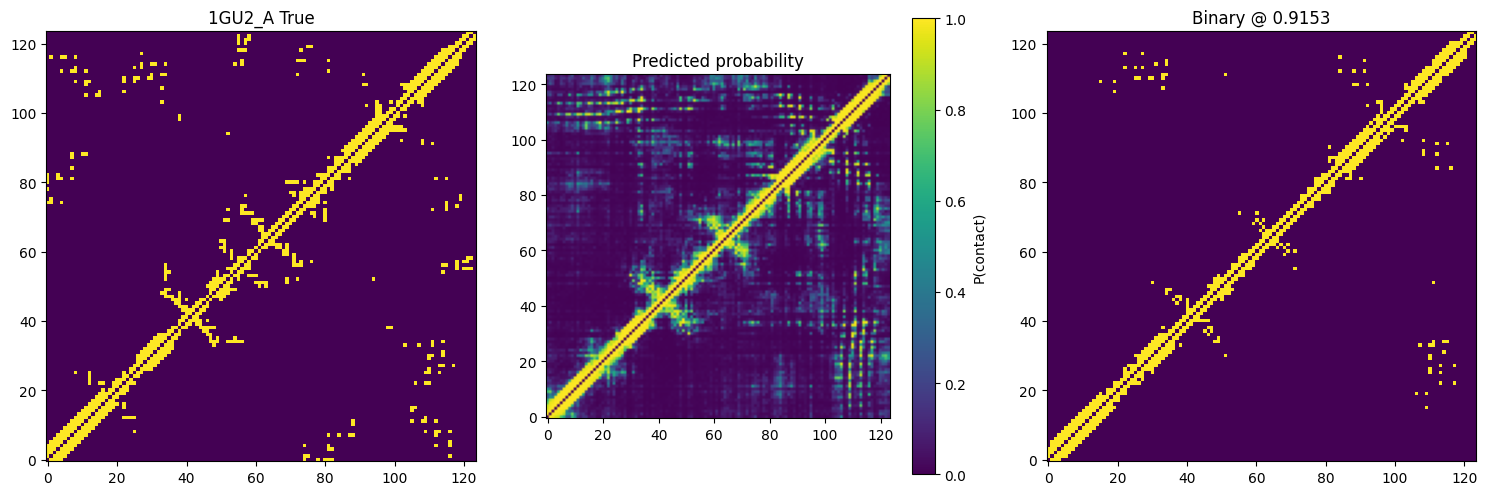

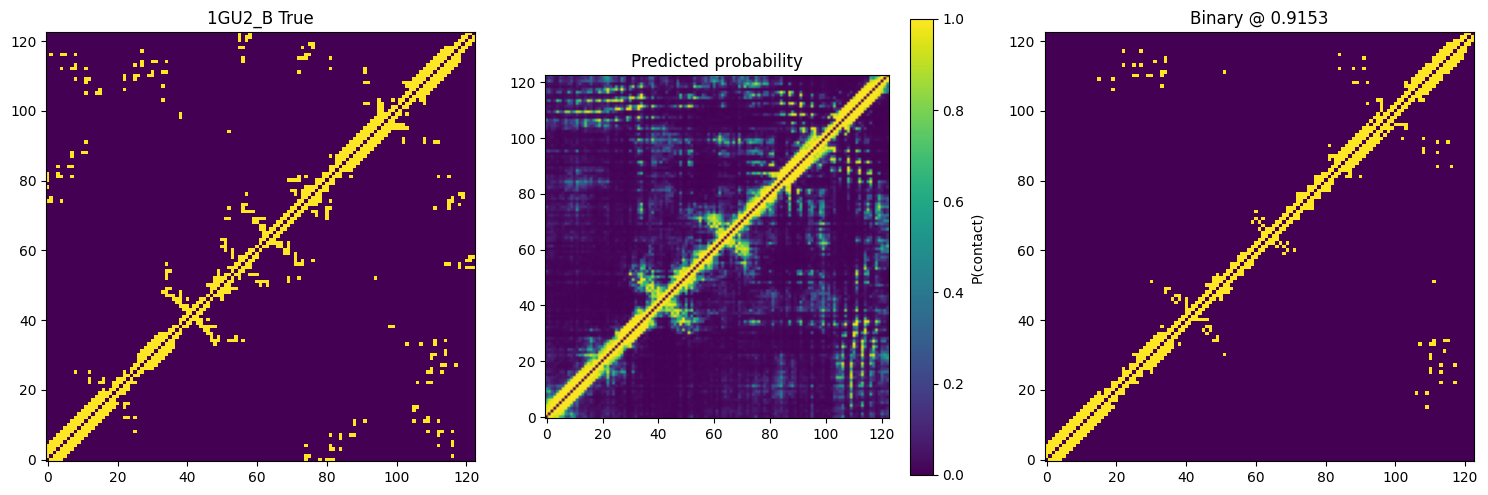

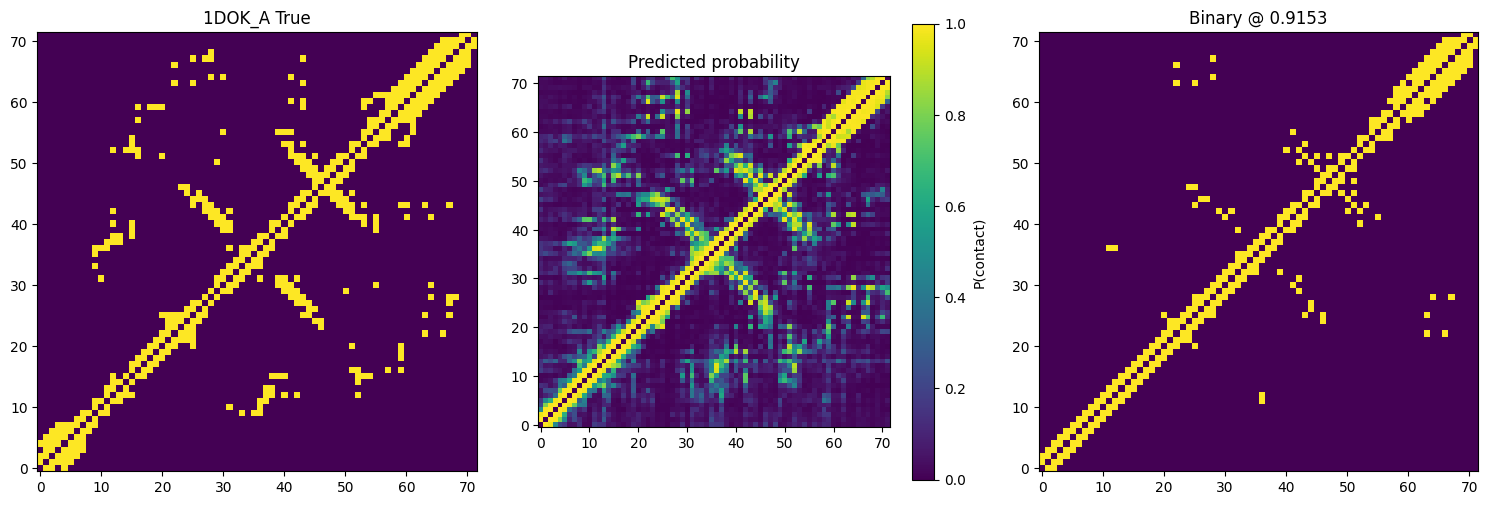

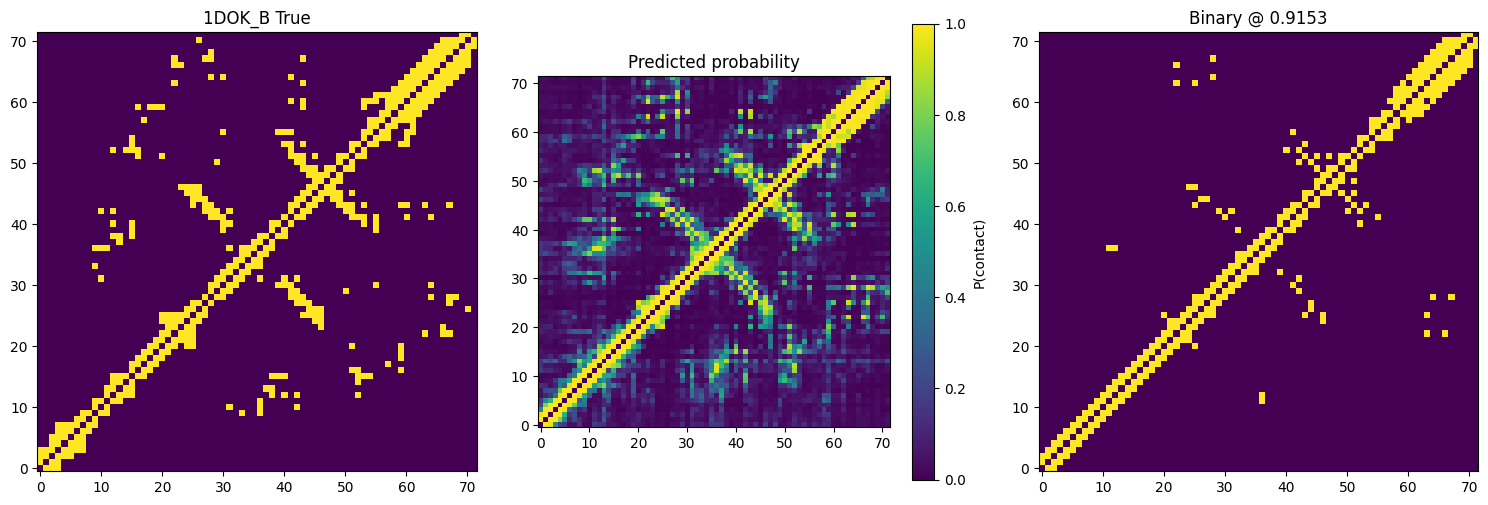

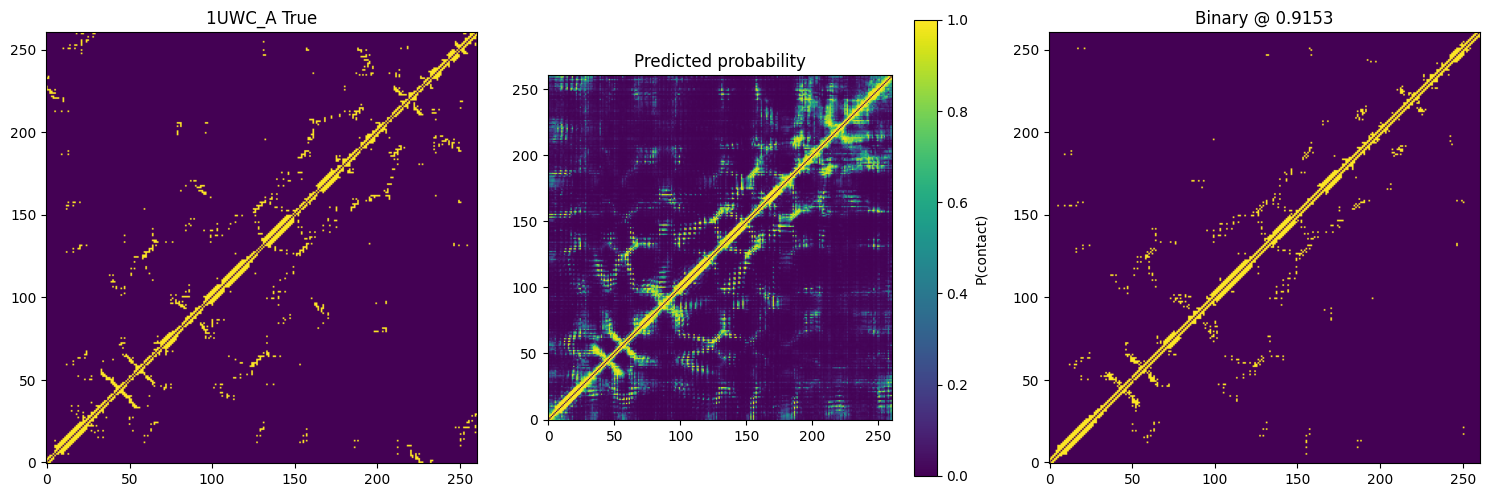

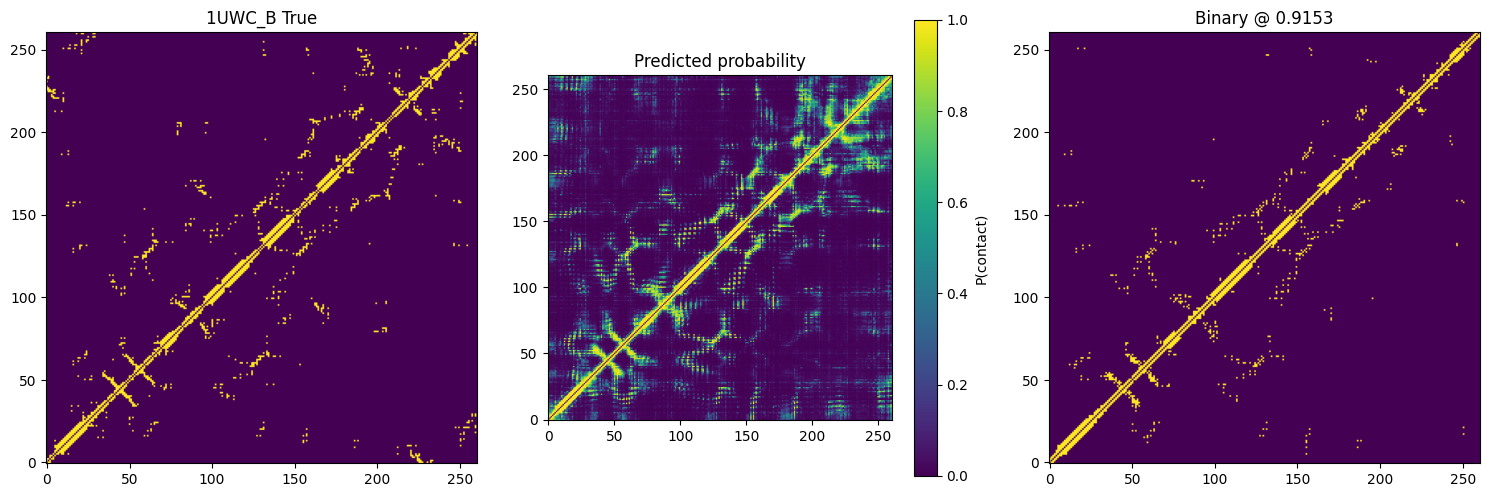

In [ ]:
# ============================================================
# TEST CONTACT MAPS: TRUE / PROBABILITY / BINARY
# ============================================================

import matplotlib.pyplot as plt

plot_df = test_chain_df[
    test_chain_df.positive_contacts > 0
].head(N_PLOT_CHAINS)

for row in plot_df.itertuples(index=False):

    (
        X,
        y,
        pi,
        pj,
        seq,
        residue_numbers
    ) = compute_chain_features(
        row.protein_chain_id,
        row.pdb_id,
        row.chain
    )

    prob = final_model.predict_proba(X)[:, 1]
    pred = (
        prob >= best_threshold
    ).astype(np.int8)

    L = len(seq)

    tm = np.zeros((L, L))
    pm = np.zeros((L, L))
    bm = np.zeros((L, L))

    tm[pi, pj] = tm[pj, pi] = y
    pm[pi, pj] = pm[pj, pi] = prob
    bm[pi, pj] = bm[pj, pi] = pred

    fig, ax = plt.subplots(
        1, 3,
        figsize=(15, 5)
    )

    ax[0].imshow(
        tm,
        vmin=0,
        vmax=1,
        origin="lower"
    )
    ax[0].set_title(
        f"{row.protein_chain_id} True"
    )

    im = ax[1].imshow(
        pm,
        vmin=0,
        vmax=1,
        origin="lower"
    )
    ax[1].set_title(
        "Predicted probability"
    )

    ax[2].imshow(
        bm,
        vmin=0,
        vmax=1,
        origin="lower"
    )
    ax[2].set_title(
        f"Binary @ {best_threshold:.4f}"
    )

    fig.colorbar(
        im,
        ax=ax[1],
        label="P(contact)"
    )

    plt.tight_layout()
    plt.show()

    del X, y, pi, pj, prob, pred
    del tm, pm, bm
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [ ]:
# ============================================================
# EXPORT TEST CONTACTS
# ============================================================

pairwise_path = (
    RESULT_DIR /
    "test_protein_contact_pairs.csv"
)

summary_path = (
    RESULT_DIR /
    "test_protein_contact_summary.csv"
)

first = True
summaries = []

for row in test_chain_df.itertuples(index=False):

    (
        X,
        y,
        pi,
        pj,
        seq,
        rn
    ) = compute_chain_features(
        row.protein_chain_id,
        row.pdb_id,
        row.chain
    )

    prob = final_model.predict_proba(X)[:, 1]
    pred = (
        prob >= best_threshold
    ).astype(np.int8)

    # Keep only actual or predicted contacts.
    keep = (y == 1) | (pred == 1)

    sa = np.array(list(seq))

    out = pd.DataFrame({
        "protein_chain_id":
            row.protein_chain_id,
        "pdb_id":
            row.pdb_id,
        "chain":
            row.chain,
        "i_zero_based":
            pi[keep],
        "j_zero_based":
            pj[keep],
        "i_one_based":
            pi[keep] + 1,
        "j_one_based":
            pj[keep] + 1,
        "residue_i":
            sa[pi[keep]],
        "residue_j":
            sa[pj[keep]],
        "pdb_residue_i":
            rn[pi[keep]],
        "pdb_residue_j":
            rn[pj[keep]],
        "actual_contact":
            y[keep],
        "predicted_contact_probability":
            prob[keep],
        "predicted_contact":
            pred[keep]
    })

    out.to_csv(
        pairwise_path,
        mode="w" if first else "a",
        header=first,
        index=False
    )

    first = False

    summaries.append({
        "protein_chain_id":
            row.protein_chain_id,
        "pdb_id":
            row.pdb_id,
        "chain":
            row.chain,
        "sequence":
            seq,
        "length":
            len(seq),
        "actual_contacts":
            int(y.sum()),
        "predicted_contacts":
            int(pred.sum()),
        "reported_union_pairs":
            int(keep.sum()),
        "protein_average_precision":
            average_precision_score(y, prob)
            if y.sum() else np.nan,
        "protein_precision":
            precision_score(
                y, pred, zero_division=0
            ),
        "protein_recall":
            recall_score(
                y, pred, zero_division=0
            ),
        "protein_f1":
            f1_score(
                y, pred, zero_division=0
            )
    })

    del X, y, pi, pj, seq, rn
    del prob, pred, keep, sa, out
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(
    summaries
).to_csv(
    summary_path,
    index=False
)

print("Contact-pair CSV:", pairwise_path)
print("Protein summary CSV:", summary_path)
print("Frozen threshold:", best_threshold)


In [ ]:
# ============================================================
# FINAL OUTPUTS
# ============================================================
print('Selected model:',best_model_name); print('Frozen validation threshold:',best_threshold); print('Test metrics:'); print(test_summary_df.to_string(index=False)); print('\nOutput files:'); [print(p) for p in sorted(RESULT_DIR.glob('*'))]

Selected model: LightGBM
Frozen validation threshold: 0.9153476357460022
Test metrics:
   model  frozen_validation_threshold  overall_average_precision  overall_roc_auc  precision   recall      f1  test_pairs  test_positive_contacts  test_contact_prevalence
LightGBM                     0.915348                    0.83193         0.978782   0.807212 0.718254 0.76014     3608263                  136783                 0.037908

Output files:
/kaggle/working/esm_contact_v3/results/feature_extraction_status.csv
/kaggle/working/esm_contact_v3/results/final_test_metrics.csv
/kaggle/working/esm_contact_v3/results/per_chain_test_metrics.csv
/kaggle/working/esm_contact_v3/results/per_chain_validation.csv
/kaggle/working/esm_contact_v3/results/split_summary.csv
/kaggle/working/esm_contact_v3/results/test_protein_contact_pairs.csv
/kaggle/working/esm_contact_v3/results/test_protein_contact_summary.csv
/kaggle/working/esm_contact_v3/results/train_X.dat
/kaggle/working/esm_contact_v3/results/train_

[None, None, None, None, None, None, None, None, None, None, None, None]